In [1]:
# ===========================================================
# Cell 1: Imports
# ===========================================================
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


In [2]:
# ===========================================================
# Cell 2: Normal population (e.g., LIG conductivity)
# ===========================================================
N = 300
mu = 50
sigma = 8

population = rng.normal(mu, sigma, size=N)
population_mean = population.mean()
population_std = population.std(ddof=1)

population_mean, population_std


(np.float64(49.67136876798704), np.float64(7.442174869399483))

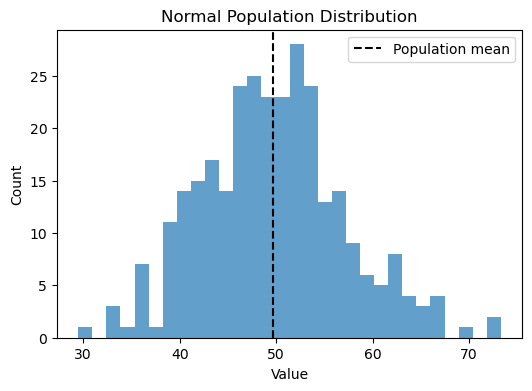

In [3]:
# ===========================================================
# Cell 3: Population distribution
# ===========================================================
plt.figure(figsize=(6,4))
plt.hist(population, bins=30, alpha=0.7)
plt.axvline(population_mean, color='k', linestyle='--', label="Population mean")
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Normal Population Distribution")
plt.legend()
plt.show()


In [4]:
# ===========================================================
# Cell 4: Central Limit Theorem
# ===========================================================
sample_size = 20      # size of each sample
n_means = 1000        # number of samples

means = [
    rng.choice(population, size=sample_size, replace=False).mean()
    for _ in range(n_means)
]


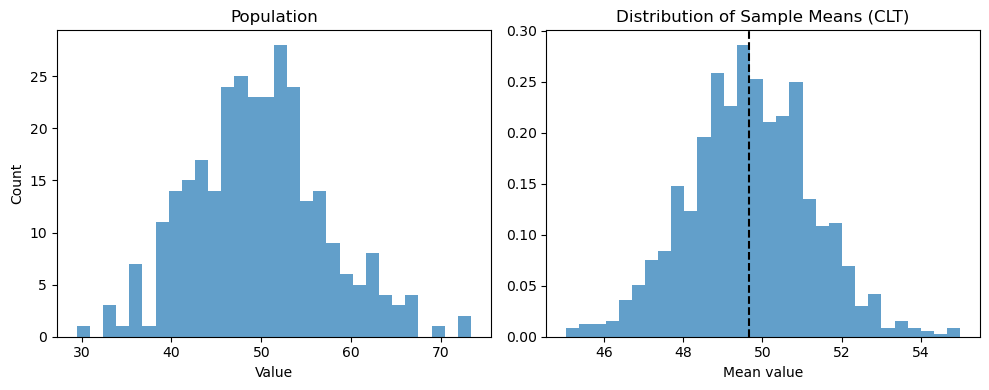

In [5]:
# ===========================================================
# Cell 5: CLT visualization
# ===========================================================
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# Raw data
ax[0].hist(population, bins=30, alpha=0.7)
ax[0].set_title("Population")
ax[0].set_xlabel("Value")
ax[0].set_ylabel("Count")

# Sample means
ax[1].hist(means, bins=30, density=True, alpha=0.7)
ax[1].axvline(population_mean, color='k', linestyle='--')
ax[1].set_title("Distribution of Sample Means (CLT)")
ax[1].set_xlabel("Mean value")

plt.tight_layout()
plt.show()


In [6]:
# ===========================================================
# Cell 6: Second variable (e.g., conductivity vs resistance)
# ===========================================================
# Example: LIG conductivity depends on resistance + noise
Y = 0.6 * population + rng.normal(0, 5, size=N)


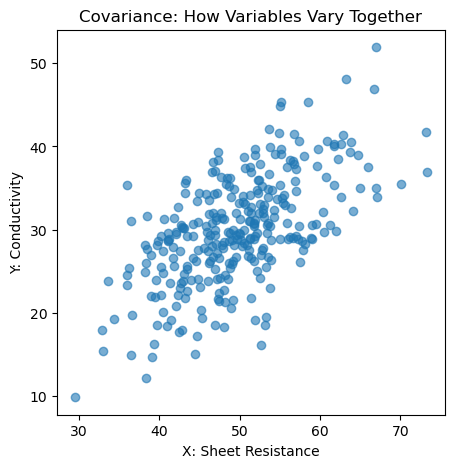

In [7]:
# ===========================================================
# Cell 7: Covariance visualization
# ===========================================================
plt.figure(figsize=(5,5))
plt.scatter(population, Y, alpha=0.6)
plt.xlabel("X: Sheet Resistance")
plt.ylabel("Y: Conductivity")
plt.title("Covariance: How Variables Vary Together")
plt.show()


In [8]:
# ===========================================================
# Cell 8: Covariance calculation
# ===========================================================
cov_xy = np.cov(population, Y)[0,1]
cov_xy


np.float64(29.683722261094076)

In [9]:
# ===========================================================
# Cell 9: Third variable (weak correlation)
# ===========================================================
Z = rng.normal(mu, sigma, size=N)  # independent variable


In [10]:
# ===========================================================
# Cell 10: Feature matrix
# ===========================================================
X = np.vstack((population, Y, Z)).T
X.shape


(300, 3)

In [11]:
# ===========================================================
# Cell 11: Covariance matrix
# ===========================================================
cov_matrix = np.cov(X, rowvar=False)
cov_matrix


array([[55.38596679, 29.68372226, -0.50727445],
       [29.68372226, 43.10535533, -3.77182125],
       [-0.50727445, -3.77182125, 64.41068162]])

In [12]:
# ===========================================================
# Cell 12: Correlation matrix
# ===========================================================
corr_matrix = np.corrcoef(X, rowvar=False)
corr_matrix


array([[ 1.        ,  0.60750922, -0.00849306],
       [ 0.60750922,  1.        , -0.07158245],
       [-0.00849306, -0.07158245,  1.        ]])

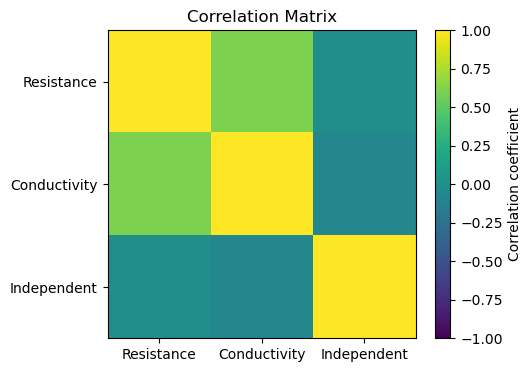

In [13]:
# ===========================================================
# Cell 13: Correlation heatmap
# ===========================================================
labels = ["Resistance", "Conductivity", "Independent"]

plt.figure(figsize=(5,4))
plt.imshow(corr_matrix, vmin=-1, vmax=1)
plt.colorbar(label="Correlation coefficient")
plt.xticks(range(3), labels)
plt.yticks(range(3), labels)
plt.title("Correlation Matrix")
plt.show()


In [14]:
# ===========================================================
# Cell A: Mean-centering the data
# ===========================================================
# Covariance measures how deviations from the mean move together

X_centered = population - population.mean()
Y_centered = Y - Y.mean()


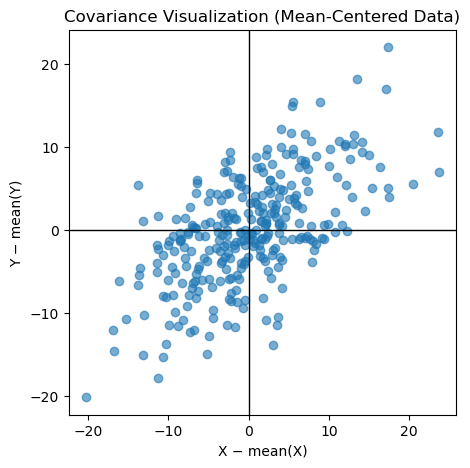

In [15]:
# ===========================================================
# Cell B: Centered scatter plot
# ===========================================================
plt.figure(figsize=(5,5))
plt.scatter(X_centered, Y_centered, alpha=0.6)

plt.axhline(0, color='k', linewidth=1)
plt.axvline(0, color='k', linewidth=1)

plt.xlabel("X − mean(X)")
plt.ylabel("Y − mean(Y)")
plt.title("Covariance Visualization (Mean-Centered Data)")
plt.show()


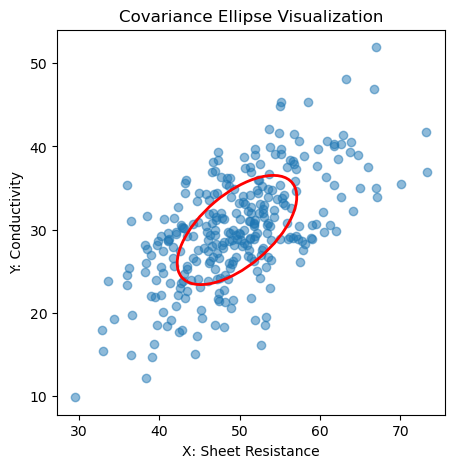

In [16]:
# ===========================================================
# Cell C: Covariance ellipse visualization
# ===========================================================
from matplotlib.patches import Ellipse

# Covariance matrix of X and Y
cov = np.cov(population, Y)

# Eigenvalues and eigenvectors (principal axes)
vals, vecs = np.linalg.eigh(cov)

# Sort eigenvalues (largest first)
order = vals.argsort()[::-1]
vals, vecs = vals[order], vecs[:, order]

# Angle of ellipse (in degrees)
theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))

# Width and height (2 standard deviations)
width, height = 2 * np.sqrt(vals)

# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(population, Y, alpha=0.5)

ellipse = Ellipse(
    xy=(population.mean(), Y.mean()),
    width=width,
    height=height,
    angle=theta,
    edgecolor='red',
    facecolor='none',
    linewidth=2
)

ax.add_patch(ellipse)
ax.set_xlabel("X: Sheet Resistance")
ax.set_ylabel("Y: Conductivity")
ax.set_title("Covariance Ellipse Visualization")
plt.show()
